Model config driven

In [2]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
val_dataset   = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)

class MLP(nn.Module):
    def __init__(self, in_dim=784, hidden=256, out_dim=10, dropout_p=0.0, use_bn=False):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(in_dim, hidden)]
        if use_bn: layers.append(nn.BatchNorm1d(hidden))
        layers.append(nn.ReLU())
        if dropout_p > 0: layers.append(nn.Dropout(dropout_p))

        layers.append(nn.Linear(hidden, hidden))
        if use_bn: layers.append(nn.BatchNorm1d(hidden))
        layers.append(nn.ReLU())
        if dropout_p > 0: layers.append(nn.Dropout(dropout_p))

        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

define the 4 config

In [3]:
configs = {
    "1_baseline":            dict(dropout_p=0.0, use_bn=False, weight_decay=0.0, early_stop=False),
    "2_dropout":              dict(dropout_p=0.3, use_bn=False, weight_decay=0.0, early_stop=False),
    "3_dropout_bn":           dict(dropout_p=0.3, use_bn=True,  weight_decay=0.0, early_stop=False),
    "4_dropout_bn_wd_es":     dict(dropout_p=0.3, use_bn=True,  weight_decay=1e-4, early_stop=True),
}

one training function hat logs everything

In [4]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

def evaluate(model, loader):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

class EarlyStopping:
    def __init__(self, patience=3, min_delta=1e-4):
        self.patience, self.min_delta = patience, min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state = None
        self.should_stop = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

def run_config(cfg, num_epochs=15, lr=1e-3):
    model = MLP(dropout_p=cfg["dropout_p"], use_bn=cfg["use_bn"]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=cfg["weight_decay"])
    stopper = EarlyStopping(patience=3) if cfg["early_stop"] else None

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer)
        val_loss, val_acc = evaluate(model, val_loader)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(val_acc)

        print(f"  epoch {epoch+1}: train_loss={tr_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        if stopper:
            stopper.step(val_loss, model)
            if stopper.should_stop:
                print(f"  early stopped at epoch {epoch+1}")
                break

    if stopper and stopper.best_state:
        model.load_state_dict(stopper.best_state)

    return history

run all 4 configu and store logs 

In [5]:
all_histories = {}

for name, cfg in configs.items():
    print(f"\n=== Running config: {name} ===")
    all_histories[name] = run_config(cfg, num_epochs=15, lr=1e-3)


=== Running config: 1_baseline ===
  epoch 1: train_loss=0.2574 val_loss=0.1192 val_acc=0.9615
  epoch 2: train_loss=0.0950 val_loss=0.0919 val_acc=0.9711
  epoch 3: train_loss=0.0666 val_loss=0.0759 val_acc=0.9747
  epoch 4: train_loss=0.0475 val_loss=0.0792 val_acc=0.9770
  epoch 5: train_loss=0.0369 val_loss=0.0683 val_acc=0.9787
  epoch 6: train_loss=0.0291 val_loss=0.0735 val_acc=0.9806
  epoch 7: train_loss=0.0264 val_loss=0.0893 val_acc=0.9735
  epoch 8: train_loss=0.0209 val_loss=0.0657 val_acc=0.9822
  epoch 9: train_loss=0.0207 val_loss=0.0828 val_acc=0.9806
  epoch 10: train_loss=0.0179 val_loss=0.0779 val_acc=0.9808
  epoch 11: train_loss=0.0171 val_loss=0.0809 val_acc=0.9809
  epoch 12: train_loss=0.0162 val_loss=0.0954 val_acc=0.9799
  epoch 13: train_loss=0.0118 val_loss=0.1026 val_acc=0.9775
  epoch 14: train_loss=0.0130 val_loss=0.1071 val_acc=0.9782
  epoch 15: train_loss=0.0125 val_loss=0.1022 val_acc=0.9781

=== Running config: 2_dropout ===
  epoch 1: train_loss=0

Plot comparision curve 

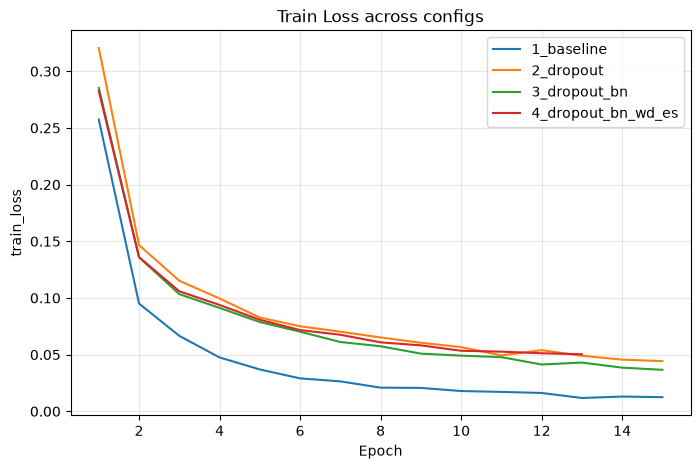

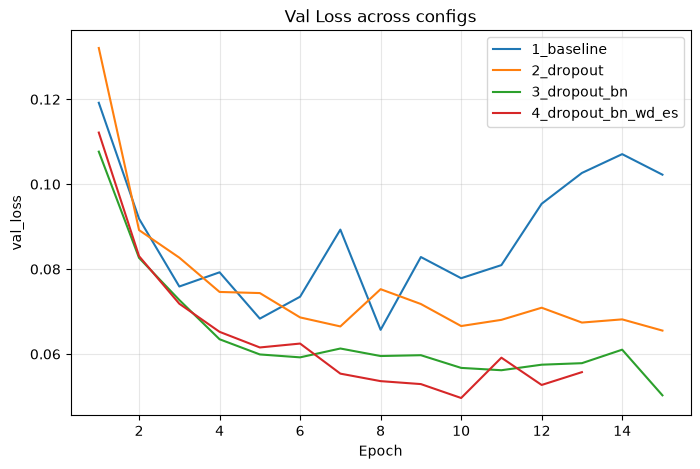

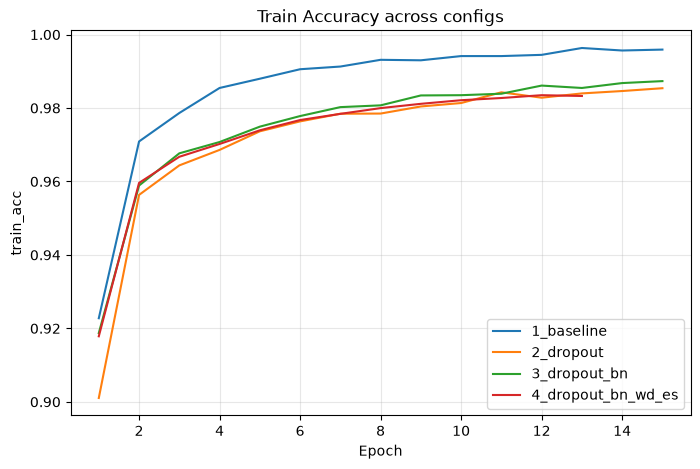

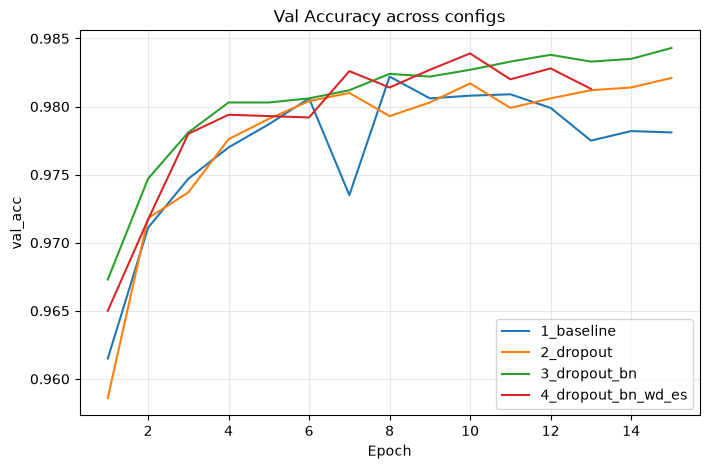

In [6]:
def plot_comparison(all_histories, metric, title):
    plt.figure(figsize=(8, 5))
    for name, hist in all_histories.items():
        epochs = range(1, len(hist[metric]) + 1)
        plt.plot(epochs, hist[metric], label=name)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_comparison(all_histories, "train_loss", "Train Loss across configs")
plot_comparison(all_histories, "val_loss",   "Val Loss across configs")
plot_comparison(all_histories, "train_acc",  "Train Accuracy across configs")
plot_comparison(all_histories, "val_acc",    "Val Accuracy across configs")

In [7]:
print(f"{'Config':<20}{'Final Train Loss':<20}{'Final Val Loss':<18}{'Final Val Acc':<15}")
for name, hist in all_histories.items():
    print(f"{name:<20}{hist['train_loss'][-1]:<20.4f}{hist['val_loss'][-1]:<18.4f}{hist['val_acc'][-1]:<15.4f}")

Config              Final Train Loss    Final Val Loss    Final Val Acc  
1_baseline          0.0125              0.1022            0.9781         
2_dropout           0.0443              0.0655            0.9821         
3_dropout_bn        0.0366              0.0503            0.9843         
4_dropout_bn_wd_es  0.0504              0.0557            0.9813         
